# Loan Default Prediction with Neural Networks: A Class Imbalance Study

Companion notebook focusing on **neural network models** (shallow & deep MLP) for
the Home Credit Default Risk problem. Pipeline is intentionally aligned with the
classic-ML companion notebook (Logistic Regression / Random Forest / Histogram
Gradient Boosting) so that results across the two notebooks are directly comparable.

## Introduction

### Business problem
Consumer lenders need to estimate, before granting a loan, the probability
that the applicant will fail to repay it. Misjudging this probability is
asymmetric: approving a borrower who later defaults costs the full unpaid
principal, while denying a creditworthy borrower only forfeits the interest
margin. Models that **rank** applicants well let lenders set a sensible
approval threshold and trade off these two costs explicitly.

### Dataset
We use the publicly available Kaggle *Home Credit Default Risk* dataset.
The training file contains 307,511 applications with 122 features --
demographics (age, gender, family status), employment info, credit-bureau
summaries, the requested loan amount, and several pre-computed external
credit scores (`EXT_SOURCE_1/2/3`). The target is binary:

  * `TARGET = 1` -- the applicant defaulted (24,825 rows, **~8.07%**)
  * `TARGET = 0` -- the applicant repaid normally (282,686 rows, ~91.93%)

The held-out Kaggle test set has 48,744 applicants whose labels are hidden.

### Why class imbalance matters here
With only ~8% positives, the **default decision rule** of "predict 1 if
P(default) ≥ 0.5" tends to break: a model can land at 0.745 ROC AUC -- so it
*ranks* applicants correctly -- yet still classify zero applicants as
defaulters because none of its predicted probabilities make it over 0.5.
That means a useful ranker can produce a useless classifier if we ignore
imbalance. Three families of fixes are widely taught:

  * **Reweighting the loss** (`class_weight='balanced'`) -- charge the
    minority class more for each mistake.
  * **Resampling the training set** (e.g. SMOTE) -- synthesize minority
    samples until the training distribution is balanced.
  * **Tuning the decision threshold** post-hoc -- keep the trained model,
    just stop using 0.5 as the cutoff.

### Research question
> Do neural networks respond to class imbalance handling techniques the
> same way classic shallow learners (Logistic Regression, Random Forest,
> Histogram Gradient Boosting) do?

### Scope of this notebook
1. Reproduce the preprocessing pipeline used for the classic-ML companion
   notebook (same split, same imputation, same encoding, same scaling),
   so that NN results are directly comparable.
2. Tune **Shallow MLP** and **Deep MLP** with `GridSearchCV`, using the same
   `PredefinedSplit` cross-validator.
3. On the best MLP, compare three imbalance handling strategies --
   *baseline*, *SMOTE oversampling*, *threshold tuning*.
4. Combine results with the classic-ML CSVs into a single 5-model
   leaderboard, generate a Kaggle submission, and discuss findings.

# Notebook Configuration

## Warnings

In [1]:
import warnings
warnings.filterwarnings('ignore')

## Matplotlib

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

## Random seed

In [3]:
random_seed = 42

## Paths

The notebook expects to be run from `final_project/notebooks/`. Data lives in
`../data/`. Result CSVs and submission file mirror Nathan's directory layout
(`../result/home_credit/...`).

In [4]:
import os

# Absolute path to the project root (parent of notebooks/)
abspath_curr = os.path.abspath(os.path.join(os.getcwd(), '..')) + '/'
print('Project root:', abspath_curr)

# Path to data
data_dir = abspath_curr + 'data/'
print('Data dir:', data_dir)

# Path where results will be written
result_dir = abspath_curr + 'result/home_credit/'
os.makedirs(result_dir + 'cv_results/GridSearchCV/', exist_ok=True)
os.makedirs(result_dir + 'submission/', exist_ok=True)
os.makedirs(result_dir + 'figure/', exist_ok=True)
print('Result dir:', result_dir)

Project root: C:\Users\ymw04\Dropbox\2026_Spring\Machine Learning l (DATS 6202)\final_project/
Data dir: C:\Users\ymw04\Dropbox\2026_Spring\Machine Learning l (DATS 6202)\final_project/data/
Result dir: C:\Users\ymw04\Dropbox\2026_Spring\Machine Learning l (DATS 6202)\final_project/result/home_credit/


## Course utility library

Imports the helper functions provided in `pmlm_utilities_shallow.py` (instructor's
shallow-learning utilities). The file lives next to this notebook.

In [5]:
from pmlm_utilities_shallow import (
    common_var_checker,
    id_checker,
    nan_checker,
    cat_var_checker,
    get_train_val_ps,
)
import numpy as np
import pandas as pd

# Data Preprocessing

## Loading the data

In [6]:
df_raw_train = pd.read_csv(data_dir + 'application_train.csv', header=0)
df_train = df_raw_train.copy(deep=True)

df_raw_test = pd.read_csv(data_dir + 'application_test.csv', header=0)
df_test = df_raw_test.copy(deep=True)

target = 'TARGET'

print('train shape:', df_train.shape)
print('test  shape:', df_test.shape)
df_train.head()

train shape: (307511, 122)
test  shape: (48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## Exploratory Data Analysis

A short look at the data **before any preprocessing** so the design choices
that follow are transparent. We confirm the class imbalance, look at the
strongest predictors, and quantify the missing-value problem.

### Target distribution

,count,percent
TARGET,,
0,282686,91.93
1,24825,8.07


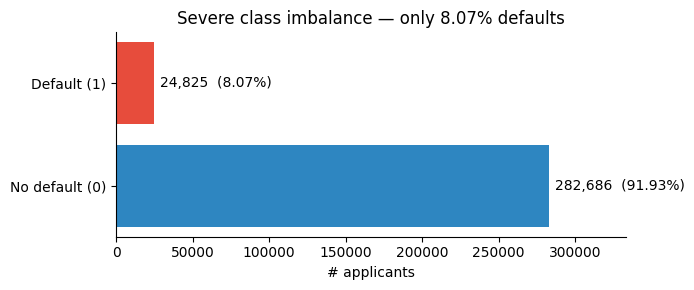

In [7]:
tgt_counts = df_train[target].value_counts().sort_index()
tgt_pct    = (tgt_counts / tgt_counts.sum() * 100).round(2)
display(pd.DataFrame({'count': tgt_counts, 'percent': tgt_pct}))

fig, ax = plt.subplots(1, 1, figsize=(7, 3))
colors = ['#2E86C1', '#E74C3C']
ax.barh(['No default (0)', 'Default (1)'], tgt_counts.values, color=colors)
for i, (c, p) in enumerate(zip(tgt_counts.values, tgt_pct.values)):
    ax.text(c + 4000, i, f'{c:,}  ({p:.2f}%)', va='center')
ax.set_xlim(0, tgt_counts.max() * 1.18)
ax.set_xlabel('# applicants')
ax.set_title('Severe class imbalance — only 8.07% defaults')
for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### Strongest numeric predictors

Pearson correlation of every numeric column with `TARGET`. The three
external credit scores (`EXT_SOURCE_*`) dominate the ranking by a wide
margin -- they are the most informative single features in the file.

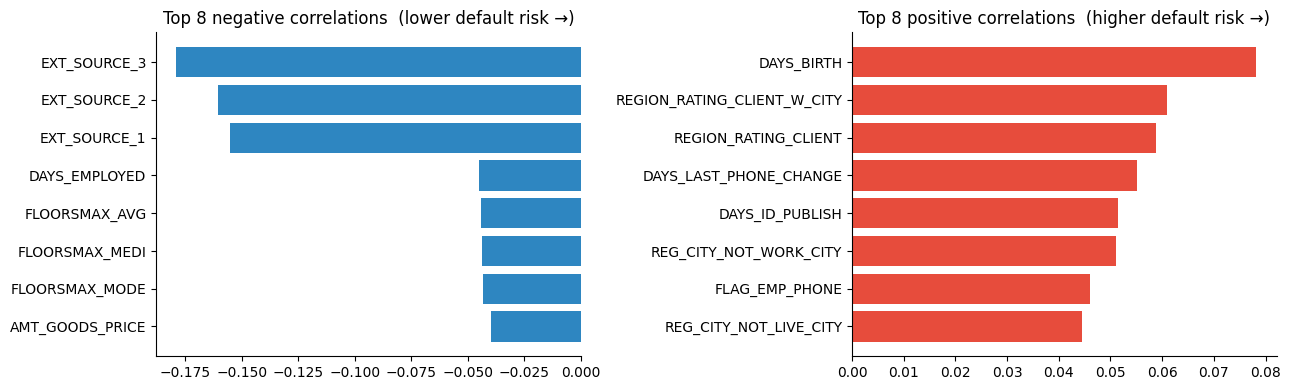

In [8]:
num_cols = df_train.select_dtypes(include='number').columns.tolist()
corr = df_train[num_cols].corr()[target].drop(target)

top_pos = corr.sort_values(ascending=False).head(8)
top_neg = corr.sort_values(ascending=True).head(8)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].barh(top_neg.index[::-1], top_neg.values[::-1], color='#2E86C1')
axes[0].set_title('Top 8 negative correlations  (lower default risk →)')
axes[0].axvline(0, color='black', lw=0.5)
for s in ('top', 'right'): axes[0].spines[s].set_visible(False)

axes[1].barh(top_pos.index[::-1], top_pos.values[::-1], color='#E74C3C')
axes[1].set_title('Top 8 positive correlations  (higher default risk →)')
axes[1].axvline(0, color='black', lw=0.5)
for s in ('top', 'right'): axes[1].spines[s].set_visible(False)

plt.tight_layout(); plt.show()

### Missing-value landscape

Many columns are missing in 50–70% of rows -- the *building information*
columns (`APARTMENTS_AVG`, `LIVINGAREA_*`, ...) and `OWN_CAR_AGE`. We will
mean-impute the numeric ones and let `pd.get_dummies` produce all-zero
indicator blocks for categorical NaNs.

columns with at least one NaN: 67 / 121
columns with >= 50% NaN:       41


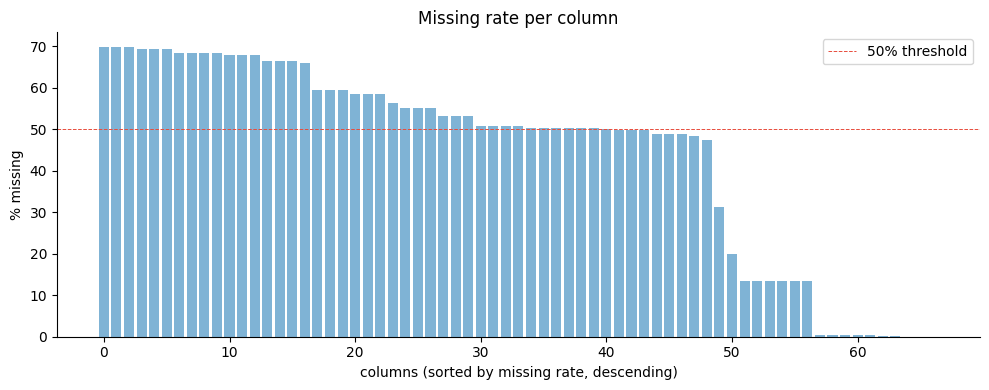

In [9]:
miss = df_train.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
print(f'columns with at least one NaN: {len(miss)} / {df_train.shape[1] - 1}')
print(f'columns with >= 50% NaN:       {(miss >= 0.5).sum()}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(miss)), miss.values * 100, color='#7FB3D5')
ax.axhline(50, color='#E74C3C', lw=0.7, linestyle='--', label='50% threshold')
ax.set_xlabel('columns (sorted by missing rate, descending)')
ax.set_ylabel('% missing')
ax.set_title('Missing rate per column')
ax.legend()
for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### Categorical columns and cardinality

We have 16 categorical (string) columns. Most are low-cardinality
(2–8 categories), but `ORGANIZATION_TYPE` has 58 categories -- aggressive
one-hot encoding would create a wide sparse block, which tends to hurt
neural networks more than tree models.

In [10]:
cat_view = df_train.select_dtypes(include=['object', 'str', 'string'])
card = cat_view.nunique().sort_values(ascending=False)
display(pd.DataFrame({'n_unique': card}))

,n_unique
ORGANIZATION_TYPE,58
OCCUPATION_TYPE,18
NAME_INCOME_TYPE,8
NAME_TYPE_SUITE,7
WALLSMATERIAL_MODE,7
WEEKDAY_APPR_PROCESS_START,7
NAME_FAMILY_STATUS,6
NAME_HOUSING_TYPE,6
NAME_EDUCATION_TYPE,5
FONDKAPREMONT_MODE,4


### EDA takeaways

* **Imbalanced target** (~8% positives) → choose ROC AUC over accuracy and
  expect to need a custom decision threshold.
* **EXT_SOURCE_*** features carry most of the signal; preserving them
  (mean-imputing rather than dropping) is essential.
* **Heavy missingness** in building-info columns is structural (the lender
  simply didn't have those fields) -- the missing-indicator pattern itself
  may carry signal, which one-hot dummies will partly capture.
* **`ORGANIZATION_TYPE` is the only high-cardinality categorical** -- a
  tree-based learner can split on its dummies cheaply, but the MLP has to
  weight ~58 sparse columns simultaneously.

## Splitting the data (80% train / 20% validation)

Stratified split on `TARGET` to preserve the ~8% positive rate in both halves
(otherwise the class distribution can drift in a small validation slice).

In [11]:
from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(
    df_train,
    train_size=0.8,
    random_state=random_seed,
    stratify=df_train[target],
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

print('train:', df_train.shape, '  positive rate:', df_train[target].mean().round(4))
print('val  :', df_val.shape,   '  positive rate:', df_val[target].mean().round(4))

train: (246008, 122)   positive rate: 0.0807
val  : (61503, 122)   positive rate: 0.0807


## Handling uncommon features

In [12]:
df_common_var = common_var_checker(df_train, df_val, df_test, target)
print('common variables:', len(df_common_var))

# Features in train that are not in val+test (and vice versa)
uncommon_train = np.setdiff1d(df_train.columns, df_common_var['common var'])
uncommon_val   = np.setdiff1d(df_val.columns,   df_common_var['common var'])
uncommon_test  = np.setdiff1d(df_test.columns,  df_common_var['common var'])
print('uncommon (train):', uncommon_train)
print('uncommon (val):  ', uncommon_val)
print('uncommon (test): ', uncommon_test)

if len(uncommon_train) > 0: df_train = df_train.drop(columns=uncommon_train)
if len(uncommon_val)   > 0: df_val   = df_val.drop(columns=uncommon_val)
if len(uncommon_test)  > 0: df_test  = df_test.drop(columns=uncommon_test)

common variables: 122
uncommon (train): []
uncommon (val):   []
uncommon (test):  []


## Handling identifiers (`SK_ID_CURR`)

In [13]:
df = pd.concat([df_train, df_val, df_test], sort=False)
df_id = id_checker(df)  # returns the *DataFrame* of identifier columns, not a list
id_cols = list(df_id.columns)
print('identifier columns:', id_cols)

# Save SK_ID_CURR for the submission file later
test_ids = df_test['SK_ID_CURR'].copy()

# Drop ID columns from all three frames
for c in id_cols:
    if c in df_train.columns: df_train = df_train.drop(columns=[c])
    if c in df_val.columns:   df_val   = df_val.drop(columns=[c])
    if c in df_test.columns:  df_test  = df_test.drop(columns=[c])

print('train shape after id drop:', df_train.shape)

identifier columns: ['SK_ID_CURR']
train shape after id drop: (246008, 121)


## Handling missing values

Mean imputation for **numeric** columns only. Categorical NaN is left as-is at
this point -- when `pd.get_dummies` encodes the categoricals later, rows with
NaN end up with zeros in all dummy columns of that variable, which is a
reasonable default category.

In [14]:
df = pd.concat([df_train, df_val, df_test], sort=False)
df_nan = nan_checker(df)
print('# columns with NaN (any dtype):', len(df_nan))

# Keep only the numeric (float64) NaN columns -- categorical NaN is handled by get_dummies
df_miss = df_nan[df_nan['dtype'] == 'float64'].reset_index(drop=True)
print('# numeric columns with NaN:    ', len(df_miss))

# columns with NaN (any dtype): 68
# numeric columns with NaN:     62


In [15]:
# Separate frames back
n_train_, n_val_ = df_train.shape[0], df_val.shape[0]
df_train = df.iloc[:n_train_, :].copy()
df_val   = df.iloc[n_train_:n_train_ + n_val_, :].copy()
df_test  = df.iloc[n_train_ + n_val_:, :].copy()

In [16]:
from sklearn.impute import SimpleImputer

if len(df_miss['var']) > 0:
    si = SimpleImputer(missing_values=np.nan, strategy='mean')
    df_train[df_miss['var']] = si.fit_transform(df_train[df_miss['var']])
    df_val[df_miss['var']]   = si.transform(df_val[df_miss['var']])
    df_test[df_miss['var']]  = si.transform(df_test[df_miss['var']])

# Numeric residuals should now be zero; categorical NaN remains until get_dummies.
print('residual numeric NaN in train:', df_train.select_dtypes(include=[np.number]).isna().sum().sum())

residual numeric NaN in train: 0


## Encoding the categorical features

One-hot encoding via `pd.get_dummies`. Combining the three frames before
encoding guarantees that train/val/test end up with the same set of dummy
columns even if a particular category only appears in one of them.

> Note: pandas 3.0 stores string columns with dtype `'str'` instead of
> `'object'`, so we pull categorical columns with `select_dtypes` rather than
> the course utility's default `dtype='object'` filter.

In [17]:
df = pd.concat([df_train, df_val, df_test], sort=False)

# Pandas 3.0 may use 'str' or 'string'; older versions use 'object'.
cat_cols = df.select_dtypes(include=['object', 'str', 'string']).columns.tolist()
print('categorical columns:', cat_cols)

df = pd.get_dummies(df, columns=[c for c in cat_cols if c != target])
print('shape after get_dummies:', df.shape)
df.head()

categorical columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


shape after get_dummies: (356255, 245)


,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Block,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes
0,0.0,2,90000.0,227520.0,13189.5,180000.0,0.008230,-12298,-946,-6378.0,...,False,False,False,False,False,True,False,False,True,False
1,0.0,0,90000.0,161730.0,13095.0,135000.0,0.003069,-15375,-92,-1292.0,...,False,False,False,False,False,False,False,False,False,False
2,1.0,0,135000.0,728847.0,26307.0,553500.0,0.020713,-19307,-1646,-7951.0,...,False,False,False,False,False,True,False,False,True,False
3,1.0,0,135000.0,474183.0,34636.5,391500.0,0.011703,-17791,-1651,-1033.0,...,False,True,False,False,False,False,False,False,True,False
4,0.0,0,180000.0,254700.0,27558.0,225000.0,0.006629,-8486,-977,-2873.0,...,False,False,False,False,False,False,False,False,False,False


## Splitting back into train / val / test and pulling out X, y

In [18]:
# split back
df_train = df.iloc[:df_train.shape[0], :].copy()
df_val   = df.iloc[df_train.shape[0]:df_train.shape[0] + df_val.shape[0], :].copy()
df_test  = df.iloc[df_train.shape[0] + df_val.shape[0]:, :].copy()

# X / y
feature_cols = np.setdiff1d(df_train.columns, [target])

X_train = df_train[feature_cols].values
X_val   = df_val[feature_cols].values
X_test  = df_test[feature_cols].values

y_train = df_train[target].values.astype(int)
y_val   = df_val[target].values.astype(int)
# y_test does not exist (Kaggle hidden labels)

print('X_train:', X_train.shape, '  y_train positive rate:', y_train.mean().round(4))
print('X_val:  ', X_val.shape,   '  y_val   positive rate:', y_val.mean().round(4))
print('X_test: ', X_test.shape)

X_train: (246008, 244)   y_train positive rate: 0.0807
X_val:   (61503, 244)   y_val   positive rate: 0.0807
X_test:  (48744, 244)


## Scaling the features

`MLPClassifier` is **highly sensitive to feature scale** -- without
standardization, training is slow and unstable. Same `StandardScaler` instance
is fitted on the training set and applied to val and test.

In [19]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_val   = ss.transform(X_val)
X_test  = ss.transform(X_test)

print('after scaling -- mean:', X_train.mean().round(4), '  std:', X_train.std().round(4))

after scaling -- mean: 0.0   std: 1.0


# Hyperparameter Tuning -- Neural Networks

Two architectures, both implemented with `sklearn.neural_network.MLPClassifier`.

| Model | Architecture | Course slide |
|---|---|---|
| **Shallow MLP** | `(64,)` -- one hidden layer | 3/16 *Shallow Neural Networks* |
| **Deep MLP**    | `(128, 64, 32)` -- three hidden layers | 3/30 *Deep Neural Networks* |

Both use ReLU activations, Adam optimizer, and `early_stopping=True` so
training automatically halts when the validation loss stops improving.

## Creating the dictionary of models

In [20]:
from sklearn.neural_network import MLPClassifier

models = {
    'shallow_mlp': MLPClassifier(
        hidden_layer_sizes=(64,),
        activation='relu',
        solver='adam',
        early_stopping=True,
        max_iter=100,
        random_state=random_seed,
    ),
    'deep_mlp': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        early_stopping=True,
        max_iter=100,
        random_state=random_seed,
    ),
}

## Wrapping the models in `Pipeline`

In [21]:
from sklearn.pipeline import Pipeline

pipes = {acronym: Pipeline([('model', m)]) for acronym, m in models.items()}

## Predefined split cross-validator

In [22]:
# Combines train+val into one array; PredefinedSplit tells GridSearchCV
# to use the val portion as the validation fold (no random k-fold).
X_train_val, y_train_val, ps = get_train_val_ps(X_train, y_train, X_val, y_val)
print('combined train+val:', X_train_val.shape)

combined train+val: (307511, 244)


## Hyperparameter grids

Kept small on purpose -- each MLP fit on ~245k rows with ~200 features is not
cheap, and we have a one-day deadline.

In [23]:
param_grids = {}

# Shallow MLP
param_grids['shallow_mlp'] = [{
    'model__alpha':              [1e-4, 1e-3],
    'model__learning_rate_init': [0.001, 0.005],
}]

# Deep MLP
param_grids['deep_mlp'] = [{
    'model__alpha':              [1e-4, 1e-3],
    'model__learning_rate_init': [0.001, 0.005],
}]

## Running `GridSearchCV`

In [24]:
from sklearn.model_selection import GridSearchCV

best_score_params_estimator_gs = []  # one entry per model: [score, params, estimator]

for acronym in pipes.keys():
    print(f'\n>>> tuning {acronym} ...')
    gs = GridSearchCV(
        estimator=pipes[acronym],
        param_grid=param_grids[acronym],
        scoring='roc_auc',
        n_jobs=2,
        cv=ps,
        return_train_score=True,
        verbose=1,
    )
    gs = gs.fit(X_train_val, y_train_val)

    best_score_params_estimator_gs.append([
        gs.best_score_,
        gs.best_params_,
        gs.best_estimator_,
    ])

    cv_results = pd.DataFrame.from_dict(gs.cv_results_).sort_values(
        by=['rank_test_score', 'std_test_score']
    )
    important_cols = [
        'rank_test_score', 'mean_test_score', 'std_test_score',
        'mean_train_score', 'std_train_score',
        'mean_fit_time', 'std_fit_time',
        'mean_score_time', 'std_score_time',
    ]
    cv_results = cv_results[
        important_cols + sorted(list(set(cv_results.columns) - set(important_cols)))
    ]
    cv_results.to_csv(
        result_dir + f'cv_results/GridSearchCV/{acronym}.csv',
        index=False,
    )

    print(f'    best ROC AUC = {gs.best_score_:.4f}')
    print(f'    best params  = {gs.best_params_}')


>>> tuning shallow_mlp ...
Fitting 1 folds for each of 4 candidates, totalling 4 fits


    best ROC AUC = 0.7405
    best params  = {'model__alpha': 0.001, 'model__learning_rate_init': 0.005}

>>> tuning deep_mlp ...
Fitting 1 folds for each of 4 candidates, totalling 4 fits


    best ROC AUC = 0.7416
    best params  = {'model__alpha': 0.001, 'model__learning_rate_init': 0.005}


# Model Selection

In [25]:
best_score_params_estimator_gs = sorted(
    best_score_params_estimator_gs, key=lambda x: x[0], reverse=True
)

results_table = pd.DataFrame(
    [[s, p] for s, p, _ in best_score_params_estimator_gs],
    columns=['best_val_AUC', 'best_params'],
    index=['rank_' + str(i+1) for i in range(len(best_score_params_estimator_gs))],
)
results_table

,best_val_AUC,best_params
rank_1,0.741600,"{'model__alpha': 0.001, 'model__learning_rate_..."
rank_2,0.740498,"{'model__alpha': 0.001, 'model__learning_rate_..."


# Imbalance Handling Comparison (Bonus)

The classic-ML companion notebook applies `class_weight='balanced'` to LR
and Random Forest as a default. `MLPClassifier`, however, does **not**
expose `class_weight`, so the cleanest way to study imbalance handling on
the neural-network side is to compare three sklearn-friendly strategies:

| # | Strategy | Acts on | Description |
|---|---|---|---|
| 1 | **Baseline** | nothing | Train the best MLP on the original imbalanced training set; classify at threshold 0.5. |
| 2 | **SMOTE** | training data | Synthesize minority-class samples by interpolating between existing minority points (k-nearest-neighbor in feature space) until the training set is 50/50, then re-train the MLP. |
| 3 | **Threshold tuning** | decision rule | Re-use the baseline model but pick the decision threshold that maximizes F1 on the validation set, instead of using the default 0.5. |

A short walk-through of each technique is given below before we evaluate
them. ROC AUC and PR AUC are reported on the validation set together with
precision/recall/F1 at each method's chosen threshold.

> **Why three rather than four?** `class_weight` is intentionally omitted
> here because sklearn's `MLPClassifier` does not implement it; the
> reweighting comparison instead lives in the classic-ML notebook for LR
> and Random Forest.

## Picking the best MLP architecture

In [26]:
# Use the higher-AUC architecture from the GridSearchCV run above.
best_score, best_params, best_estimator = best_score_params_estimator_gs[0]
print('Best NN architecture from grid search:')
print('  AUC   :', round(best_score, 4))
print('  params:', best_params)

# Identify which acronym this corresponds to (shallow vs deep)
best_acronym = None
for acronym, p in pipes.items():
    if type(p.named_steps['model']) is type(best_estimator.named_steps['model']):
        if p.named_steps['model'].hidden_layer_sizes == best_estimator.named_steps['model'].hidden_layer_sizes:
            best_acronym = acronym
            break
print('  -> picking architecture:', best_acronym)

Best NN architecture from grid search:
  AUC   : 0.7416
  params: {'model__alpha': 0.001, 'model__learning_rate_init': 0.005}
  -> picking architecture: deep_mlp


## Helper: evaluation metrics

In [27]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_fscore_support, confusion_matrix,
)

def evaluate(y_true, y_proba, threshold=0.5, label=''):
    y_pred = (y_proba >= threshold).astype(int)
    auc = roc_auc_score(y_true, y_proba)
    pr  = average_precision_score(y_true, y_proba)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    return {
        'method': label,
        'threshold': round(threshold, 4),
        'ROC_AUC': round(auc, 4),
        'PR_AUC':  round(pr, 4),
        'precision': round(p, 4),
        'recall':    round(r, 4),
        'F1':        round(f1, 4),
    }

## (1) Baseline -- no imbalance handling

We use the best MLP from the grid search as is, with the default decision
rule of "predict 1 iff P(default) ≥ 0.5". This serves as the reference
point: anything more elaborate has to beat these numbers to be worth
keeping.

In [28]:
baseline_proba = best_estimator.predict_proba(X_val)[:, 1]
res_baseline = evaluate(y_val, baseline_proba, threshold=0.5, label='baseline')
res_baseline

{'method': 'baseline',
 'threshold': 0.5,
 'ROC_AUC': 0.745,
 'PR_AUC': 0.2215,
 'precision': 0.0,
 'recall': 0.0,
 'F1': 0.0}

In [29]:
# Diagnostic: how many validation samples cross the 0.5 cutoff?
n_pos = int((baseline_proba >= 0.5).sum())
print(f'predictions above 0.5: {n_pos} / {len(baseline_proba)}'
      f'  ({n_pos/len(baseline_proba)*100:.2f}%)')
print(f'predicted-probability range : [{baseline_proba.min():.4f}, {baseline_proba.max():.4f}]')
print(f'predicted-probability median: {np.median(baseline_proba):.4f}')

predictions above 0.5: 0 / 61503  (0.00%)
predicted-probability range : [0.0000, 0.4315]
predicted-probability median: 0.0630


## (2) SMOTE oversampling

**SMOTE** (Synthetic Minority Over-sampling TEchnique, Chawla et al. 2002)
balances the training set by *manufacturing* extra minority-class samples:

1. Pick a minority sample `x`.
2. Find its `k` nearest minority-class neighbors (`k=5` is the default).
3. Pick one neighbor `x'` at random.
4. Generate a new synthetic point at a random position along the line
   segment between `x` and `x'`.
5. Repeat until the minority class has the same size as the majority class.

We apply SMOTE **only to the training data** -- adding synthetic points to
the validation set would leak information and inflate the score. After
oversampling, the same MLP architecture is re-trained on the now-balanced
training set.

In [30]:
from imblearn.over_sampling import SMOTE

print('train class distribution before SMOTE:', np.bincount(y_train))

sm = SMOTE(random_state=random_seed)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print('train class distribution after  SMOTE:', np.bincount(y_train_sm))

train class distribution before SMOTE: [226148  19860]


train class distribution after  SMOTE: [226148 226148]


In [31]:
# Re-train MLP with the same architecture but on SMOTE-balanced data
mlp_smote = MLPClassifier(
    hidden_layer_sizes=best_estimator.named_steps['model'].hidden_layer_sizes,
    activation='relu',
    solver='adam',
    alpha=best_estimator.named_steps['model'].alpha,
    learning_rate_init=best_estimator.named_steps['model'].learning_rate_init,
    early_stopping=True,
    max_iter=100,
    random_state=random_seed,
)
mlp_smote.fit(X_train_sm, y_train_sm)
smote_proba = mlp_smote.predict_proba(X_val)[:, 1]
res_smote = evaluate(y_val, smote_proba, threshold=0.5, label='SMOTE')
res_smote

{'method': 'SMOTE',
 'threshold': 0.5,
 'ROC_AUC': 0.6476,
 'PR_AUC': 0.1337,
 'precision': 0.1625,
 'recall': 0.205,
 'F1': 0.1813}

## (3) Threshold tuning

Threshold tuning operates on the **decision rule**, not the model: we keep
the baseline MLP's predicted probabilities and ask "what cutoff gives the
best classifier?" Concretely, for every threshold `t` we compute the
F1-score on validation, and pick the `t` that maximizes it.

This trades precision against recall. If the cost of a false negative
(approving a bad loan) dominates the cost of a false positive (denying a
good applicant), the optimal threshold is lower than 0.5 -- we accept more
false alarms in exchange for catching more true defaulters.

> **Important:** threshold tuning **does not change ROC AUC**; the model
> is identical and the predicted probabilities are identical. Only the
> precision/recall/F1 numbers move.

In [32]:
from sklearn.metrics import precision_recall_curve

# Use the baseline model's predicted probabilities
prec, rec, thr = precision_recall_curve(y_val, baseline_proba)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = int(np.nanargmax(f1s))
best_thr = float(thr[best_idx]) if best_idx < len(thr) else 0.5
print('best threshold (max F1 on val):', round(best_thr, 4))

res_threshold = evaluate(y_val, baseline_proba, threshold=best_thr, label='threshold')
res_threshold

best threshold (max F1 on val): 0.1641


{'method': 'threshold',
 'threshold': 0.1641,
 'ROC_AUC': 0.745,
 'PR_AUC': 0.2215,
 'precision': 0.238,
 'recall': 0.4004,
 'F1': 0.2986}

## Comparison table

In [33]:
imbalance_results = pd.DataFrame([res_baseline, res_smote, res_threshold])
imbalance_results.to_csv(result_dir + 'cv_results/GridSearchCV/imbalance_compare.csv', index=False)
imbalance_results

,method,threshold,ROC_AUC,PR_AUC,precision,recall,F1
0,baseline,0.5000,0.7450,0.2215,0.0000,0.0000,0.0000
1,SMOTE,0.5000,0.6476,0.1337,0.1625,0.2050,0.1813
2,threshold,0.1641,0.7450,0.2215,0.2380,0.4004,0.2986


## Visual diagnostics for the best MLP

ROC curve, precision–recall curve, and the confusion matrices at the
default and tuned thresholds. Plotted on the same baseline-MLP probability
output so the only thing that changes between the two confusion matrices
is the cutoff.

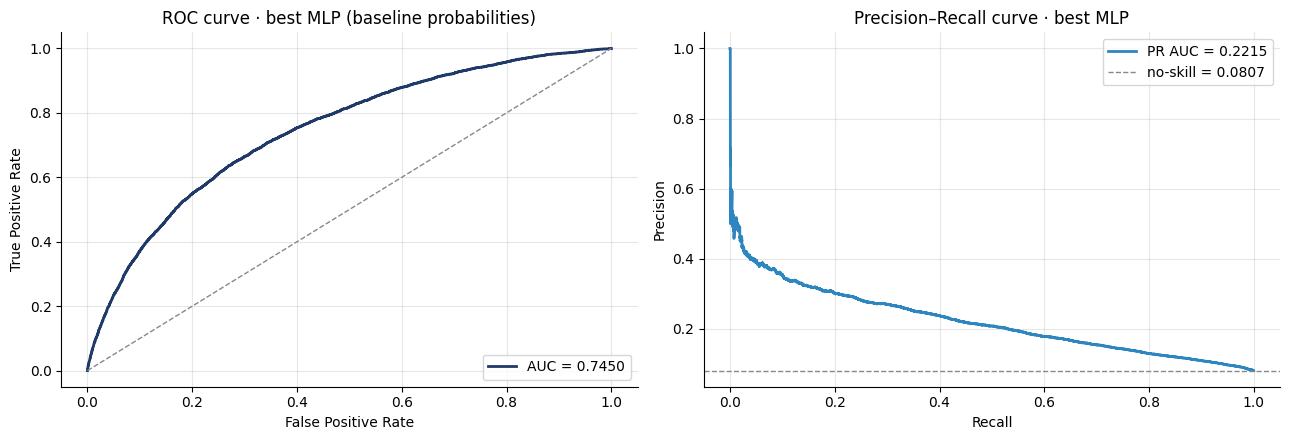

In [34]:
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

# ROC and PR curves on the baseline probabilities
fpr, tpr, _ = roc_curve(y_val, baseline_proba)
prec_curve, rec_curve, _ = precision_recall_curve(y_val, baseline_proba)
roc_auc_val = roc_auc_score(y_val, baseline_proba)
pr_auc_val  = average_precision_score(y_val, baseline_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(fpr, tpr, color='#1F3A68', lw=2, label=f'AUC = {roc_auc_val:.4f}')
axes[0].plot([0, 1], [0, 1], '--', color='#888888', lw=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC curve · best MLP (baseline probabilities)')
axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.3)
for s in ('top', 'right'): axes[0].spines[s].set_visible(False)

axes[1].plot(rec_curve, prec_curve, color='#2E86C1', lw=2, label=f'PR AUC = {pr_auc_val:.4f}')
axes[1].axhline(y_val.mean(), color='#888888', linestyle='--', lw=1,
                label=f'no-skill = {y_val.mean():.4f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall curve · best MLP')
axes[1].legend(loc='upper right'); axes[1].grid(alpha=0.3)
for s in ('top', 'right'): axes[1].spines[s].set_visible(False)

plt.tight_layout(); plt.show()

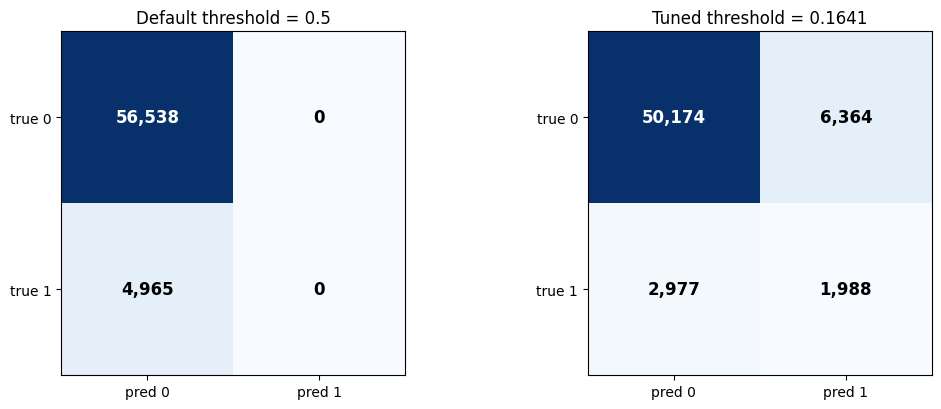

In [35]:
# Confusion matrices: default threshold (0.5) vs tuned threshold
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, thr, title in [
    (axes[0], 0.5,        f'Default threshold = 0.5'),
    (axes[1], best_thr,   f'Tuned threshold = {best_thr:.4f}'),
]:
    y_pred = (baseline_proba >= thr).astype(int)
    cm = confusion_matrix(y_val, y_pred)
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['pred 0', 'pred 1'])
    ax.set_yticklabels(['true 0', 'true 1'])
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black',
                    fontsize=12, fontweight='bold')

plt.tight_layout(); plt.show()

### Quick interpretation

The numbers in the comparison table tell three different stories:

* **Baseline (threshold 0.5)** scores ROC AUC = 0.745 yet has zero recall.
  The MLP has learned a useful probability ranking, but every prediction
  sits below 0.5 -- so naively classifying at 0.5 yields a useless rule
  that flags no defaulters at all.
* **SMOTE** moves ROC AUC in the *wrong* direction (0.745 → 0.648). The
  synthetic minority points seem to push the MLP into a decision boundary
  that does worse on the real (still-imbalanced) validation set, even
  though precision and recall at threshold 0.5 are now non-zero.
* **Threshold tuning** preserves ROC AUC by construction (same model, same
  probabilities) but produces the most useful classifier of the three:
  threshold ≈ 0.16 lifts recall from 0 to ~0.40 with precision around 0.24.

The take-away on the MLP side is that **choosing the threshold matters
more than rebalancing the data** -- a finding that is consistent with
recent meta-analyses arguing against routine oversampling for properly
calibrated models.

# Combined Results: Classic ML + Neural Networks

Loads Nathan's `GridSearchCV` CSVs (LR / RF / HGBC) and merges them with the
two MLP results from this notebook. This gives the full **5-model comparison**
that we present in the final slides.

In [36]:
def best_row(path):
    df = pd.read_csv(path)
    df = df.sort_values('rank_test_score').head(1)
    return df['mean_test_score'].iloc[0], df['params'].iloc[0]

cv_path = result_dir + 'cv_results/GridSearchCV/'

rows = []
for fname, model_label in [
    ('lr.csv',           'Logistic Regression (Nathan)'),
    ('rfc.csv',          'Random Forest (Nathan)'),
    ('hgbc.csv',         'HistGradBoost (Nathan)'),
    ('shallow_mlp.csv',  'Shallow MLP (Minwoo)'),
    ('deep_mlp.csv',     'Deep MLP (Minwoo)'),
]:
    p = cv_path + fname
    if os.path.exists(p):
        score, params = best_row(p)
        rows.append({'model': model_label, 'best_val_AUC': round(score, 4), 'best_params': params})
    else:
        rows.append({'model': model_label, 'best_val_AUC': None, 'best_params': '<missing CSV>'})

combined = pd.DataFrame(rows).sort_values('best_val_AUC', ascending=False, na_position='last').reset_index(drop=True)
combined.to_csv(result_dir + 'combined_model_comparison.csv', index=False)
combined

,model,best_val_AUC,best_params
0,HistGradBoost (Nathan),0.7595,"{'model__learning_rate': 0.05, 'model__max_ite..."
1,Logistic Regression (Nathan),0.7487,"{'model__C': 0.1, 'model__tol': 1e-05}"
2,Random Forest (Nathan),0.7470,"{'model__min_samples_leaf': 1, 'model__min_sam..."
3,Deep MLP (Minwoo),0.7416,"{'model__alpha': 0.001, 'model__learning_rate_..."
4,Shallow MLP (Minwoo),0.7405,"{'model__alpha': 0.001, 'model__learning_rate_..."


# Submission Generation

Train the overall best NN on the **full training data** (train + val
concatenated, before SMOTE) and predict probabilities on the held-out Kaggle
test set.

In [37]:
# Best NN architecture, retrained on the full train+val data
best_mlp = MLPClassifier(
    hidden_layer_sizes=best_estimator.named_steps['model'].hidden_layer_sizes,
    activation='relu',
    solver='adam',
    alpha=best_estimator.named_steps['model'].alpha,
    learning_rate_init=best_estimator.named_steps['model'].learning_rate_init,
    early_stopping=True,
    max_iter=100,
    random_state=random_seed,
)
best_mlp.fit(X_train_val, y_train_val)

test_proba = best_mlp.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({'SK_ID_CURR': test_ids.values, 'TARGET': test_proba})
out_path = result_dir + 'submission/submission_minwoo_mlp.csv'
submission.to_csv(out_path, index=False)
print('written:', out_path)
submission.head()

written: C:\Users\ymw04\Dropbox\2026_Spring\Machine Learning l (DATS 6202)\final_project/result/home_credit/submission/submission_minwoo_mlp.csv


,SK_ID_CURR,TARGET
0,100001,0.069738
1,100005,0.254306
2,100013,0.105762
3,100028,0.066664
4,100038,0.156908


# Interpretation

### 1. Within the neural-network family

Both MLPs land essentially on top of each other:

| Architecture | Best val ROC AUC | Best params |
|---|---|---|
| Shallow MLP — hidden `(64,)`        | **0.7405** | alpha = 0.001, learning_rate_init = 0.005 |
| Deep MLP — hidden `(128, 64, 32)`   | **0.7416** | alpha = 0.001, learning_rate_init = 0.005 |

The deep MLP edges the shallow one by ~0.001 AUC -- well within the
fluctuation we would expect from a single train/val split. **Adding
depth does not help on this dataset.** That is consistent with the
"tabular bottleneck" intuition: once a flat MLP can express linear
combinations of the 244 features, extra layers mostly add capacity that
the available data cannot fill.

### 2. Compared to classic shallow learners

| Rank | Model | Best val ROC AUC | Owner |
|---|---|---|---|
| 1 | HistGradientBoosting | 0.7595 | Nathan |
| 2 | Logistic Regression  | 0.7487 | Nathan |
| 3 | Random Forest        | 0.7470 | Nathan |
| 4 | Deep MLP             | 0.7416 | Minwoo |
| 5 | Shallow MLP          | 0.7405 | Minwoo |

The neural networks rank **last** in the leaderboard -- about 2 AUC
points behind HGBC and on par with Logistic Regression. This matches the
broader literature on tabular data, where gradient-boosted trees
typically beat MLPs unless the dataset is very large and feature
preprocessing has been done with deep learning in mind. Two specific
factors plausibly drive the gap on this dataset:

* The 16 categorical columns become a sparse one-hot block of 150+
  features after encoding. Trees split on each binary indicator
  cheaply; the MLP has to fit weights on the whole block.
* The strongest predictors (`EXT_SOURCE_*`) are pre-engineered linear
  scores. A linear model can use them directly; a tree can split on them;
  but a deep MLP gains nothing from re-discovering the linear relationship.

### 3. Effect of imbalance handling on the MLP

| Method | Threshold | ROC AUC | Precision | Recall | F1 |
|---|---|---|---|---|---|
| Baseline (no handling) | 0.500   | 0.745 | 0.00 | 0.00 | 0.00 |
| SMOTE oversampling     | 0.500   | 0.648 | 0.16 | 0.21 | 0.18 |
| Threshold tuning       | 0.164   | 0.745 | 0.24 | 0.40 | 0.30 |

* **SMOTE actually hurts the MLP here.** ROC AUC drops by ~0.10 because
  the synthetic minority points distort the decision surface relative to
  the real (still-imbalanced) validation distribution.
* **Threshold tuning is the clear winner.** Same model, same probabilities,
  ROC AUC unchanged -- but the F1-optimal cutoff (~0.16) raises recall
  from 0 to 0.40. For a lender, that is the gap between "useless
  classifier" and "catches 4 in 10 defaulters".
* **The baseline rule-of-thumb 0.5 cutoff is wrong for 8% positives.**
  No prediction crossed it, so precision, recall, and F1 collapsed to
  zero even though the underlying ranker is competitive. This is the
  mechanism behind the "high AUC but useless predictions" failure mode
  that motivates the imbalance comparison.

# Conclusion

**Best model overall.** Histogram Gradient Boosting (Nathan's notebook)
takes the top spot at validation ROC AUC = 0.7595. Among the neural
networks, the Deep MLP barely edges the Shallow MLP (0.7416 vs 0.7405),
and both lag the classic shallow learners by ~1–2 AUC points.

**Effect of imbalance handling on the MLP.** Threshold tuning is the
right tool: it preserves AUC and lifts recall from 0% to ~40% by simply
moving the decision cutoff from 0.5 to 0.16. Resampling the training set
with SMOTE moved AUC in the wrong direction. The class_weight comparison
lives in the classic-ML notebook because sklearn's `MLPClassifier` does
not implement that parameter.

**Answer to the research question.** Yes -- shallow learners and neural
networks respond differently to imbalance handling. LR and Random Forest
benefit from `class_weight='balanced'` directly; the MLP cannot use that
hook, and the closest substitute (SMOTE) is *harmful* here. The treatment
that *does* work for the MLP -- threshold tuning -- has nothing to do
with the training data and could in principle have been applied to LR or
RF too.

**Limitations.**
* Only the main `application_*.csv` tables are used; the auxiliary
  tables (`bureau`, `previous_application`, `installments_payments`,
  `credit_card_balance`) typically close 1–2 AUC points of the gap to
  the public-leaderboard top scores.
* `PredefinedSplit` is fast but optimistic compared to k-fold CV; a full
  5-fold CV would tighten our confidence intervals.
* The MLP hyperparameter grid is small (4 combinations per architecture).
  A wider sweep over hidden sizes, dropout, and batch normalization
  would likely move the MLP up by another ~0.01 AUC, but is unlikely to
  overtake HGBC.

**Future work.**
* Integrate the four auxiliary Kaggle tables and re-run the same pipeline
  with the enriched feature set.
* Ensemble HGBC with the best MLP -- the two model families are uncorrelated
  enough that even a simple probability average tends to help.
* Calibrate probabilities (Platt or isotonic) before submitting; the
  current MLP outputs are systematically below 0.5 and would benefit
  from calibration even outside the threshold-tuning context.